<a href="https://colab.research.google.com/github/cs23f016/CSL701_CS25_Machine-Learning-Lab/blob/main/CopyML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Ganesh Shankar Khadapkar

Roll No:CS25


# Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


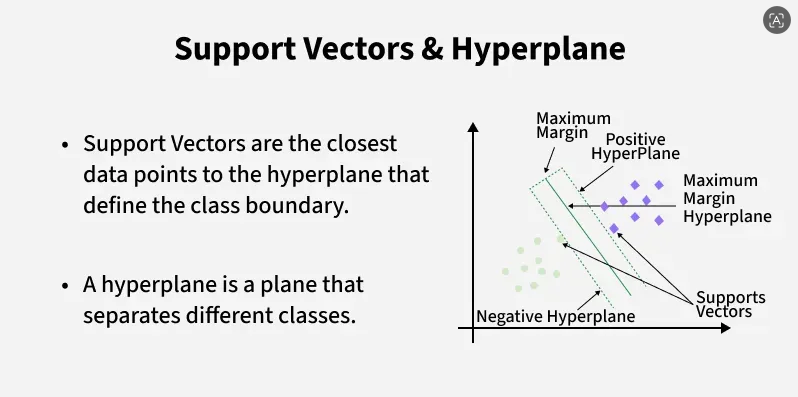
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io

# Upload CSV file
uploaded = files.upload()

# Get the uploaded filename automatically
filename = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Display first 5 records
print(df.head())

# Display shape
print("\nShape:", df.shape)

# Display column names
print("\nColumns:", df.columns.tolist())

Saving Iris (1).csv to Iris (1) (1).csv
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Shape: (150, 6)

Columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


\# Task 2: Explore the Dataset

In [4]:
# Display first 5 records
print("First 5 records:")
print(df.head())

# Display last 5 records
print("\nLast 5 records:")
print(df.tail())

# Display dataset information
print("\nDataset Information:")
print(df.info())

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display number of rows and columns
print("\nShape of Dataset:")
print(df.shape)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Display unique species
print("\nUnique Species:")
print(df["Species"].unique())

First 5 records:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Last 5 records:
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
145  Iris-virginica  
146  Iris-virginica  
147  Iris-virgini

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [5]:
# Remove Id column
df = df.drop("Id", axis=1)

# Select features
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]

# Select target
y = df["Species"]

# Display features and target
print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Display shapes
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (120, 4)
Testing data: (30, 4)
Training target: (120,)
Testing target: (30,)


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [7]:
from sklearn.svm import SVC

# Create Linear SVM model
svm_model = SVC(kernel="linear", random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions
y_pred = svm_model.predict(X_test)

# Display predictions
print("Predicted values:")
print(y_pred)

Predicted values:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

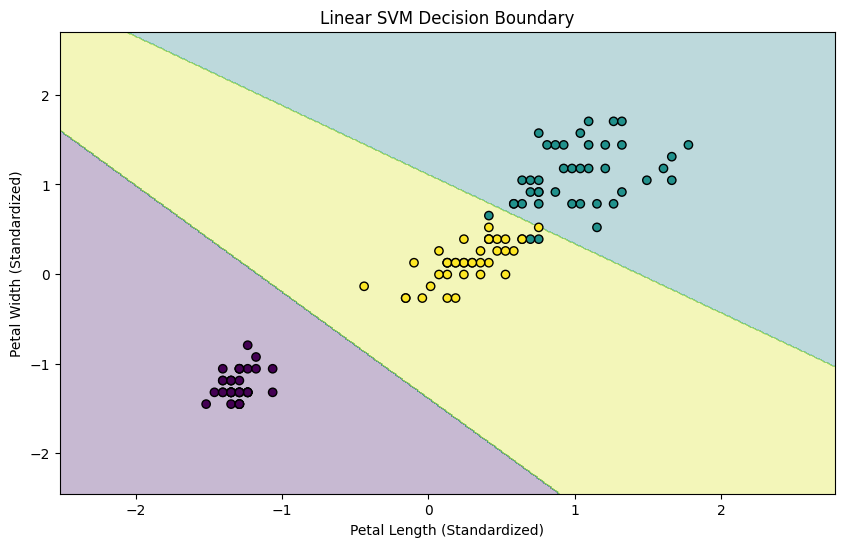

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Select two features
X_2D = df[["PetalLengthCm", "PetalWidthCm"]]
y_2D = df["Species"]

# 2. Split the data
X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(
    X_2D, y_2D,
    test_size=0.2,
    random_state=42,
    stratify=y_2D
)

# 3. Scale the data
scaler_2D = StandardScaler()

X_train_scaled = scaler_2D.fit_transform(X_train_2D)
X_test_scaled = scaler_2D.transform(X_test_2D)

# 4. Train Linear SVM
svm_2D = SVC(kernel="linear")
svm_2D.fit(X_train_scaled, y_train_2D)

# 5. Create mesh grid
x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1
y_min = X_train_scaled[:, 1].min() - 1
y_max = X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# 6. Predict for every point in the grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = svm_2D.predict(grid_points)
Z = np.array([list(y_train_2D.unique()).index(label) for label in Z])
Z = Z.reshape(xx.shape)

# 7. Plot decision boundary
plt.figure(figsize=(10, 6))

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=[list(y_train_2D.unique()).index(label) for label in y_train_2D],
    edgecolors="k"
)

plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("Linear SVM Decision Boundary")

plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

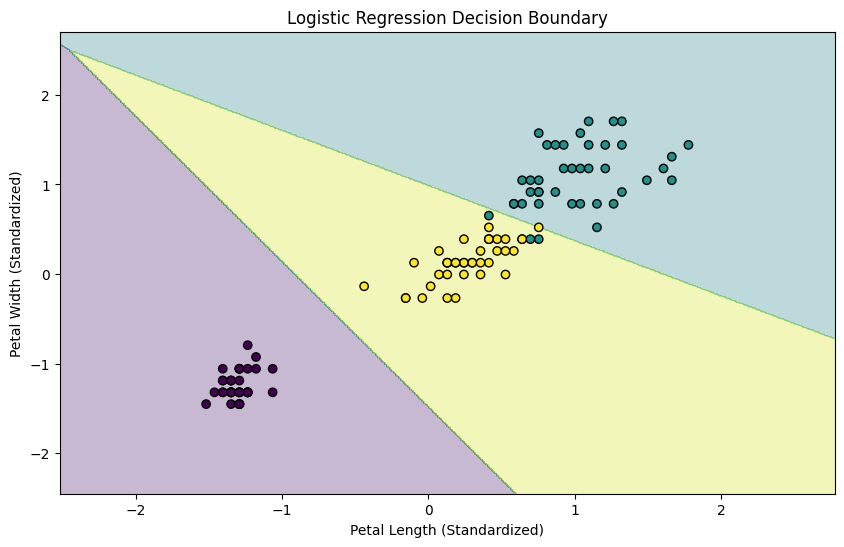

In [10]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

# 1. Create Logistic Regression model
logistic_model = LogisticRegression(max_iter=200)

# 2. Train the model using the same scaled 2-D training data
logistic_model.fit(X_train_scaled, y_train_2D)

# 3. Create mesh grid
x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1
y_min = X_train_scaled[:, 1].min() - 1
y_max = X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# 4. Predict each point in the grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = logistic_model.predict(grid_points)

# Convert class labels to numbers for plotting
classes = list(y_train_2D.unique())
Z = np.array([classes.index(label) for label in Z])
Z = Z.reshape(xx.shape)

# 5. Plot Logistic Regression decision boundary
plt.figure(figsize=(10, 6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=[classes.index(label) for label in y_train_2D],
    edgecolors="k"
)

plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("Logistic Regression Decision Boundary")

plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

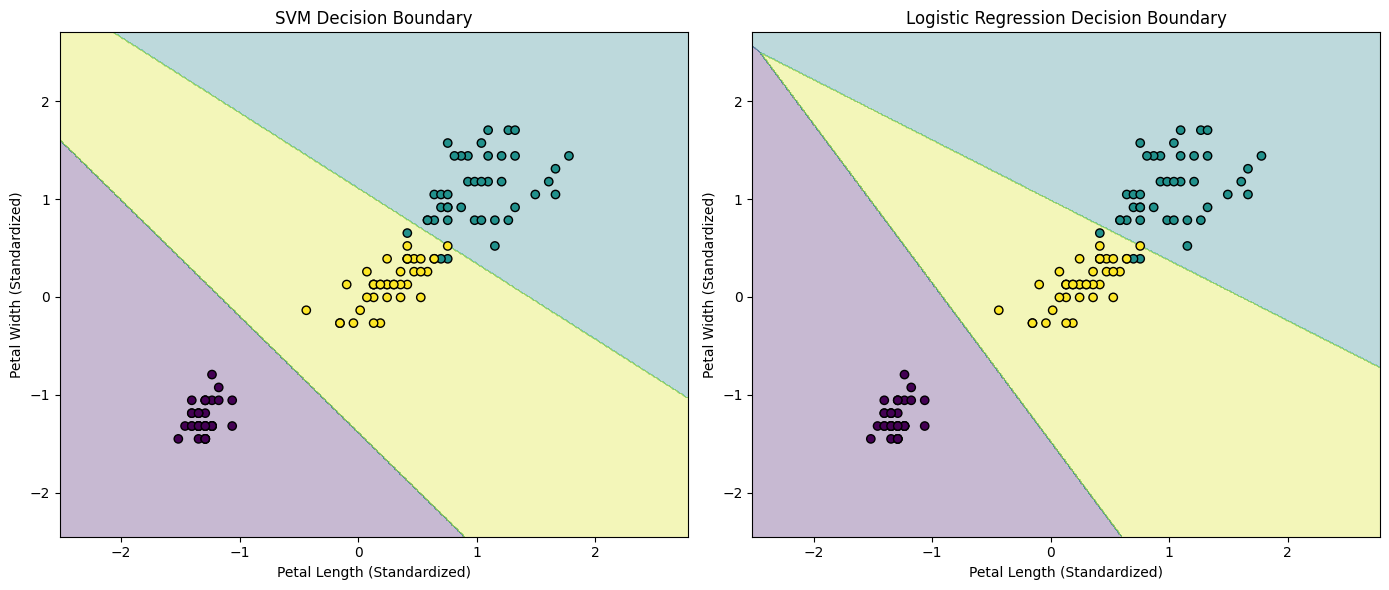

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Train models
svm_model = SVC(kernel="linear")
svm_model.fit(X_train_scaled, y_train_2D)

logistic_model = LogisticRegression(max_iter=200)
logistic_model.fit(X_train_scaled, y_train_2D)

# Create grid
x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1
y_min = X_train_scaled[:, 1].min() - 1
y_max = X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# Predictions
svm_pred = svm_model.predict(grid)
logistic_pred = logistic_model.predict(grid)

# Convert class names to numbers
classes = list(y_train_2D.unique())

svm_Z = np.array([classes.index(label) for label in svm_pred])
logistic_Z = np.array([classes.index(label) for label in logistic_pred])

svm_Z = svm_Z.reshape(xx.shape)
logistic_Z = logistic_Z.reshape(xx.shape)

# Convert actual classes to numbers
y_numbers = [classes.index(label) for label in y_train_2D]

# Plot both boundaries
plt.figure(figsize=(14, 6))

# SVM
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, svm_Z, alpha=0.3)
plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_numbers,
    edgecolors="k"
)
plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("SVM Decision Boundary")

# Logistic Regression
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, logistic_Z, alpha=0.3)
plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_numbers,
    edgecolors="k"
)
plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("Logistic Regression Decision Boundary")

plt.tight_layout()
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predictions
svm_pred = svm_model.predict(X_test_scaled)
logistic_pred = logistic_model.predict(X_test_scaled)

# Linear SVM
print("========== LINEAR SVM ==========")

svm_accuracy = accuracy_score(y_test_2D, svm_pred)
print("Accuracy:", svm_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_2D, svm_pred))

print("\nClassification Report:")
print(classification_report(y_test_2D, svm_pred))


# Logistic Regression
print("========== LOGISTIC REGRESSION ==========")

logistic_accuracy = accuracy_score(y_test_2D, logistic_pred)
print("Accuracy:", logistic_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_2D, logistic_pred))

print("\nClassification Report:")
print(classification_report(y_test_2D, logistic_pred))

========== LINEAR SVM ==========
Accuracy: 0.9333333333333333

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

========== LOGISTIC REGRESSION ==========
Accuracy: 0.9333333333333333

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg   

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.